----------------------------------------------------------------------
ПАРАМЕТРЫ ВАРИАНТА №18
----------------------------------------------------------------------
Студент: Седельников ЯН Константинович
Группа: 935-М
Целевая переменная: fitness_score
Признаки: ['workouts', 'sleep', 'nutrition']
Шум (σ): 1.0
% выбросов: 10.0%
Амплитуда выбросов: ×5
epsilon (Huber): 1.35
loss (SGD): huber
Learning rate: 0.01
Итерации SGD: 1100
----------------------------------------------------------------------

----------------------------------------------------------------------
ЭТАП 1: ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ
----------------------------------------------------------------------
Размерность данных: (500, 4)
Истинные коэффициенты:
  workouts: 1.1830
  sleep: 3.3797
  nutrition: 1.4653
Истинный intercept: 3.6232

Обучающая выборка: 350 наблюдений
Тестовая выборка: 150 наблюдений

----------------------------------------------------------------------
ЭТАП 2: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)
----

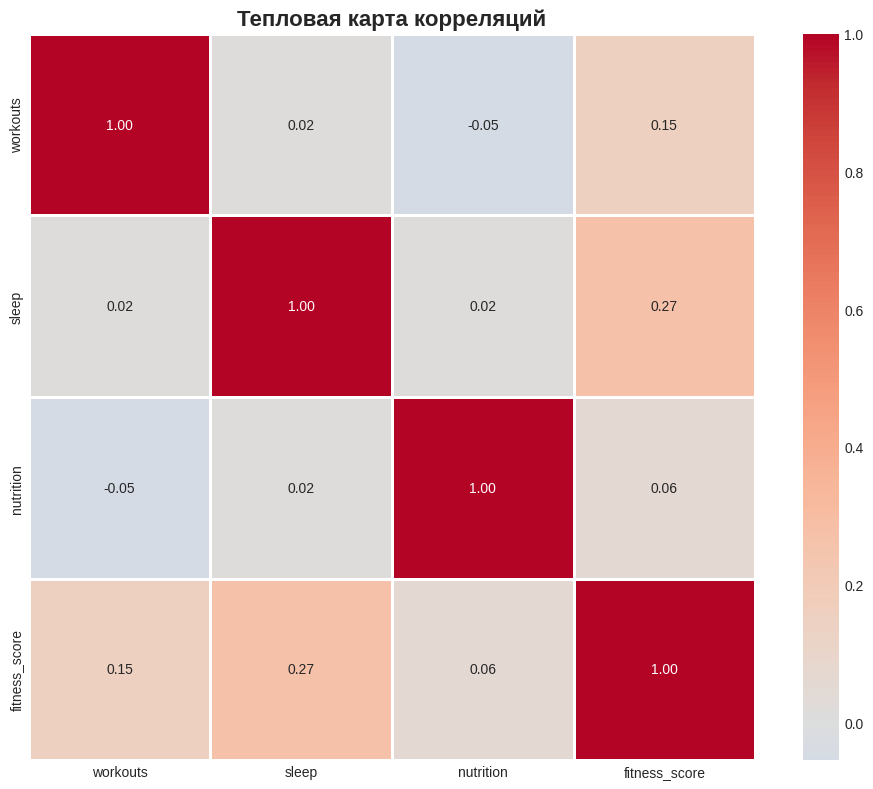

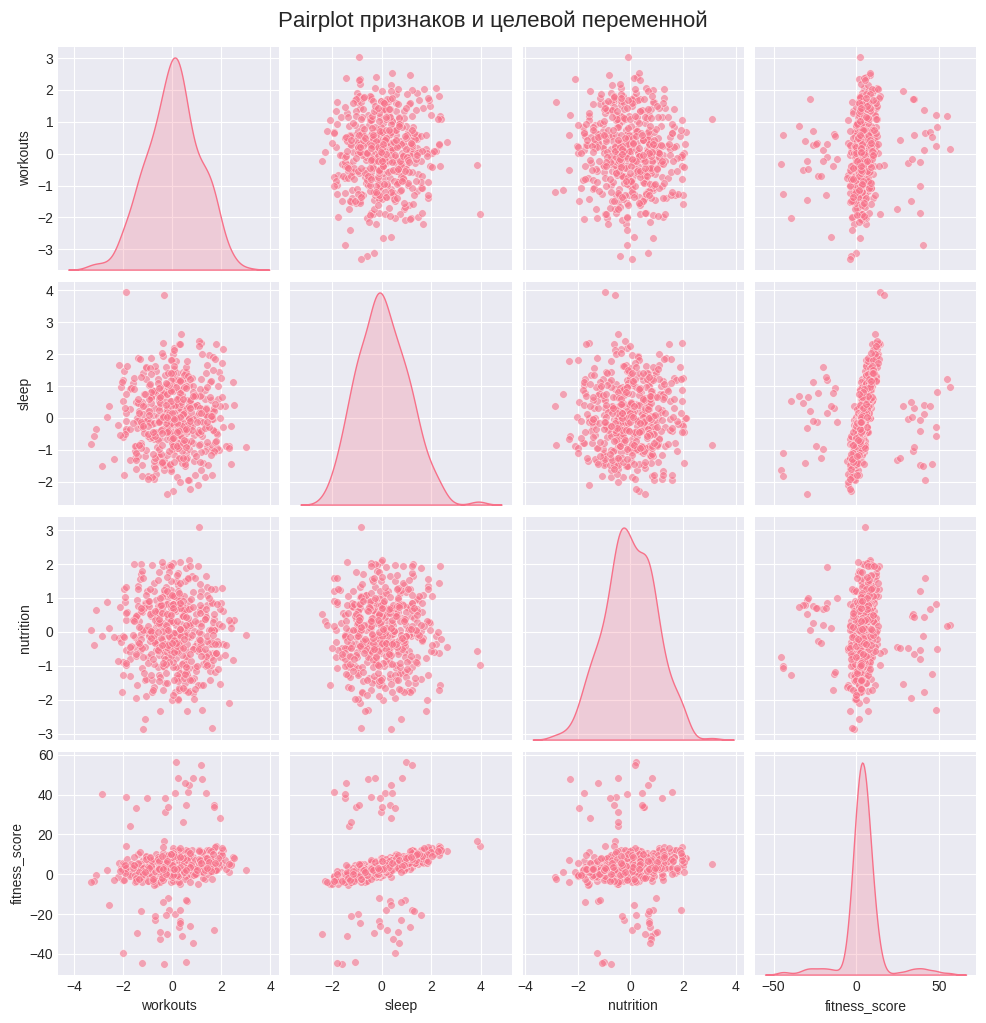

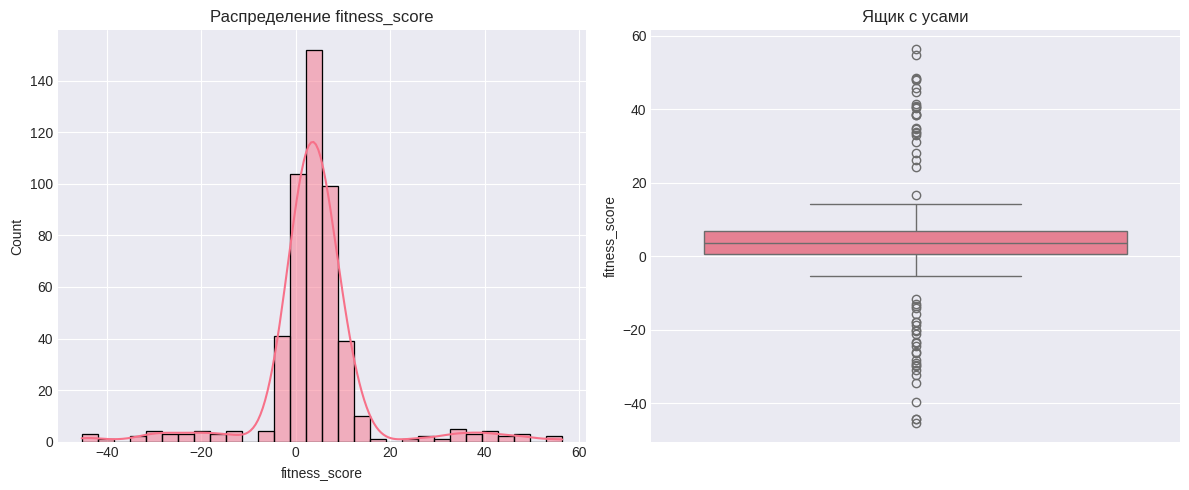

Количество выбросов (IQR): 51


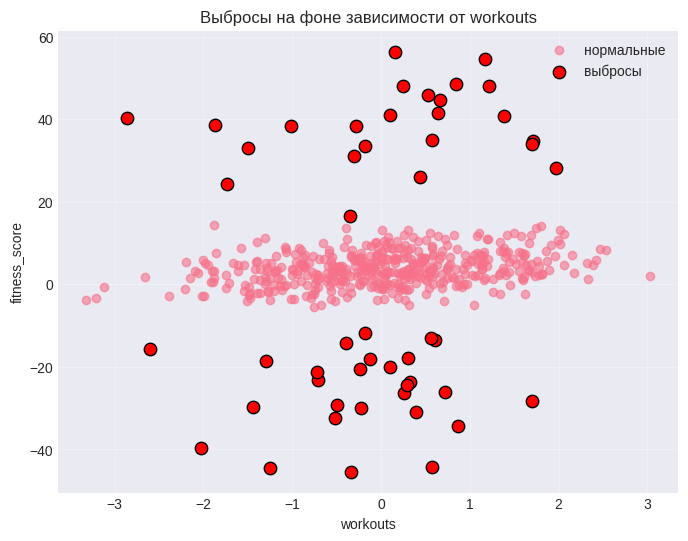


----------------------------------------------------------------------
ЭТАП 3: ОБУЧЕНИЕ МОДЕЛЕЙ
----------------------------------------------------------------------

--- Обучение Linear Regression ---
  MSE: 102.1449, MAE: 3.8902, R²: 0.1193
  Коэффициенты: [1.80152311 2.88182169 0.82112985]
  Intercept: 3.7336

--- Обучение Huber Regressor ---
  MSE: 101.8832, MAE: 3.5242, R²: 0.1216
  Коэффициенты: [1.28418591 3.51454511 1.45326682]
  Intercept: 3.6478

--- Обучение SGD Regressor (Huber) ---
  MSE: 101.8301, MAE: 3.5250, R²: 0.1220
  Коэффициенты: [1.28887928 3.50542696 1.42545063]
  Intercept: 3.6846

Сравнение истинных коэффициентов с оценкой Huber:
  workouts: истинный = 1.1830, Huber = 1.2842, разница = 0.1012
  sleep: истинный = 3.3797, Huber = 3.5145, разница = 0.1348
  nutrition: истинный = 1.4653, Huber = 1.4533, разница = 0.0120

----------------------------------------------------------------------
ЭТАП 4: ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ
-----------------------------------------

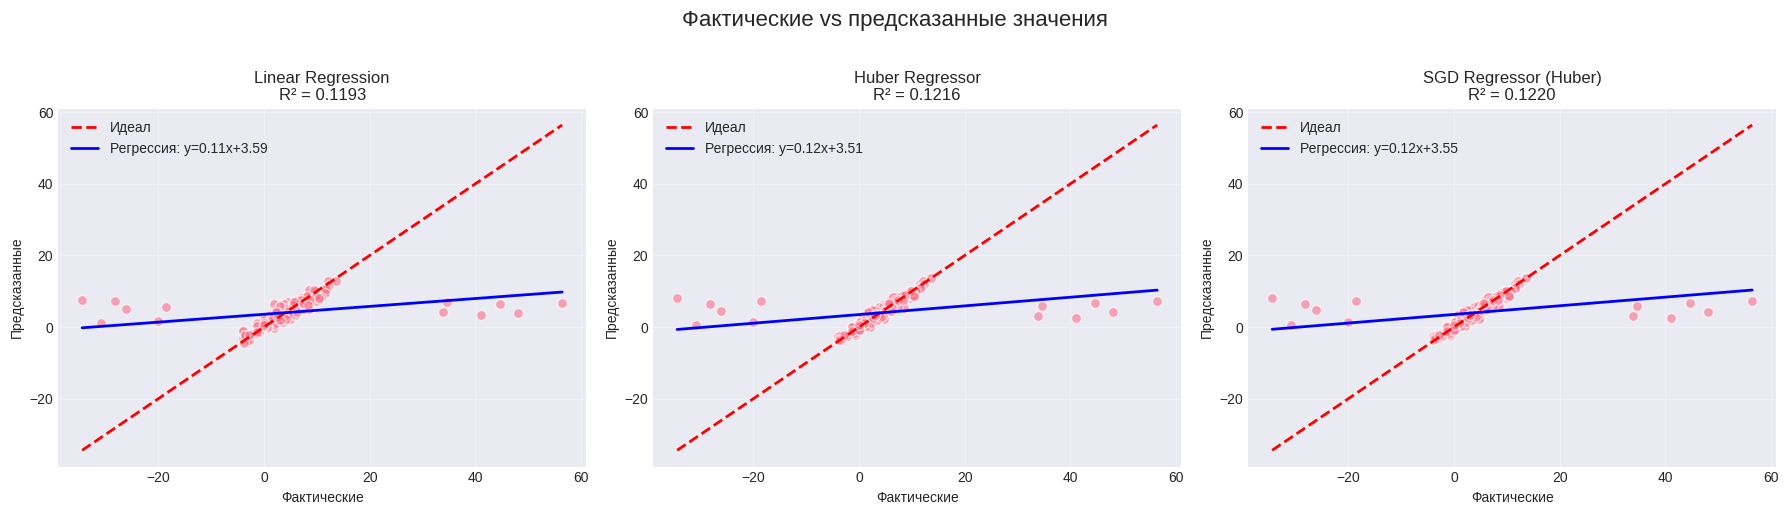

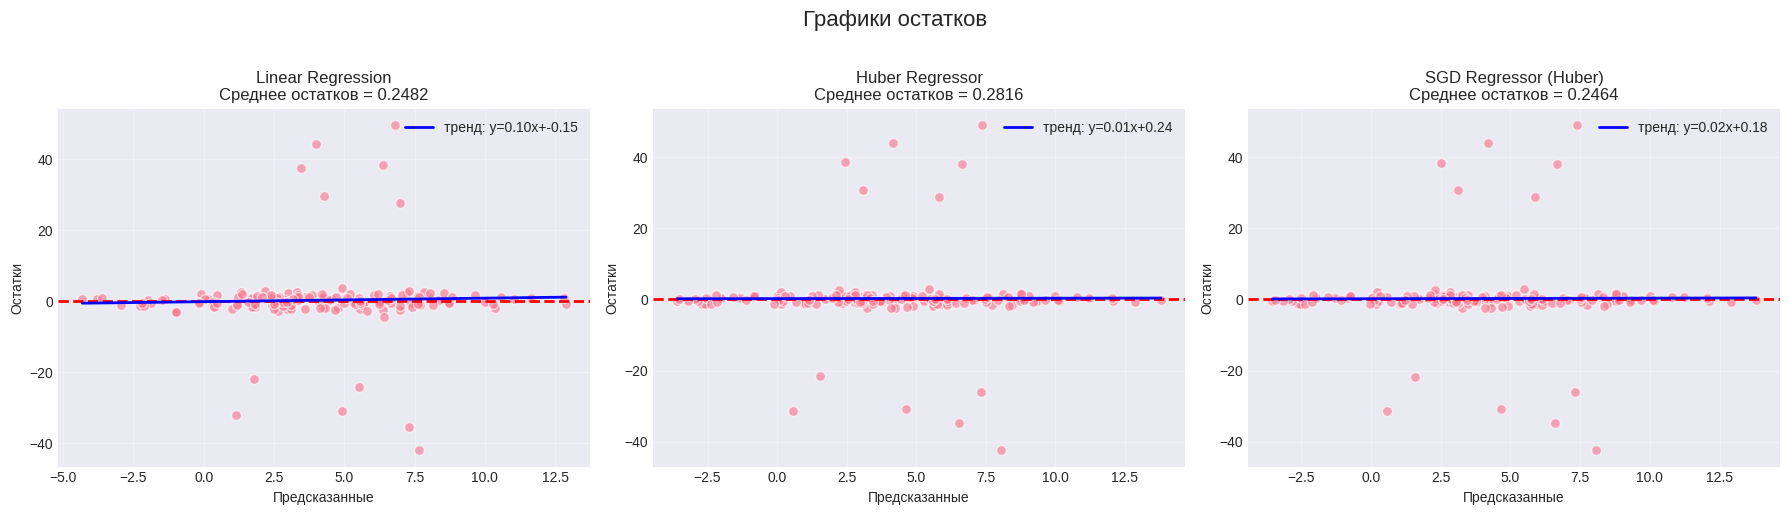

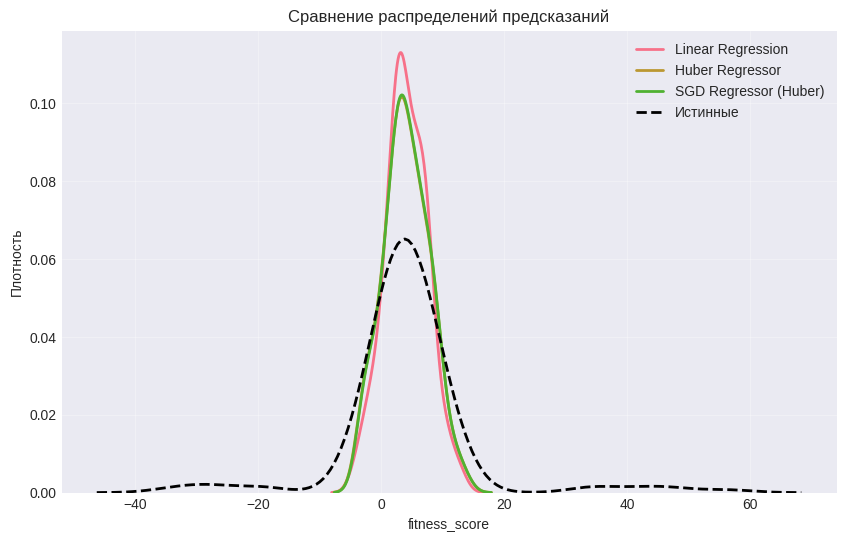


----------------------------------------------------------------------
ЭТАП 5: АНАЛИЗ УСТОЙЧИВОСТИ
----------------------------------------------------------------------
Выбросов в обучающей выборке: 39

Метрики после удаления выбросов из обучающей выборки:
Linear Regression: MSE=101.9144, MAE=3.5247, R2=0.1213
Huber Regressor: MSE=101.9308, MAE=3.5245, R2=0.1212
SGD Regressor (Huber): MSE=101.8354, MAE=3.5279, R2=0.1220


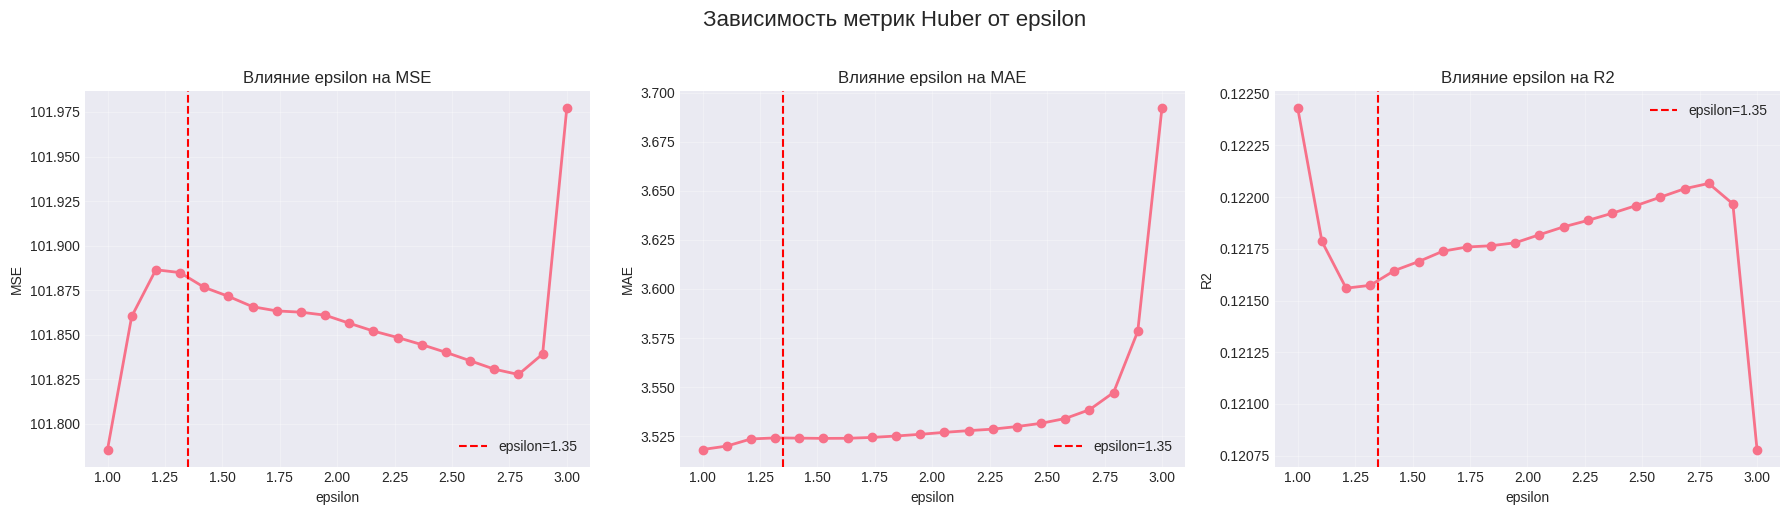


----------------------------------------------------------------------
ДОПОЛНИТЕЛЬНЫЕ ВИЗУАЛИЗАЦИИ
----------------------------------------------------------------------


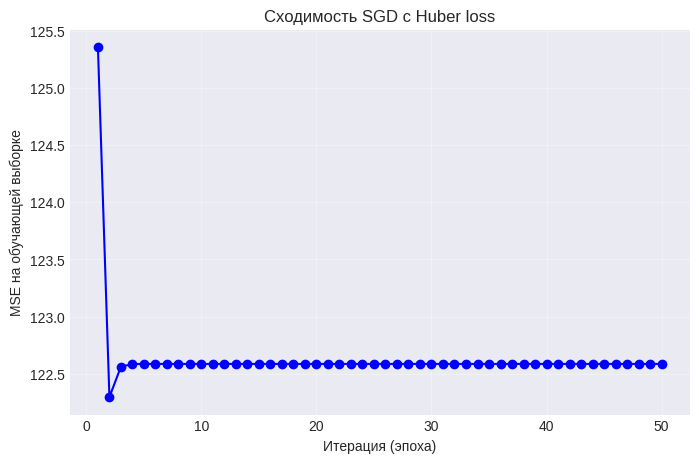

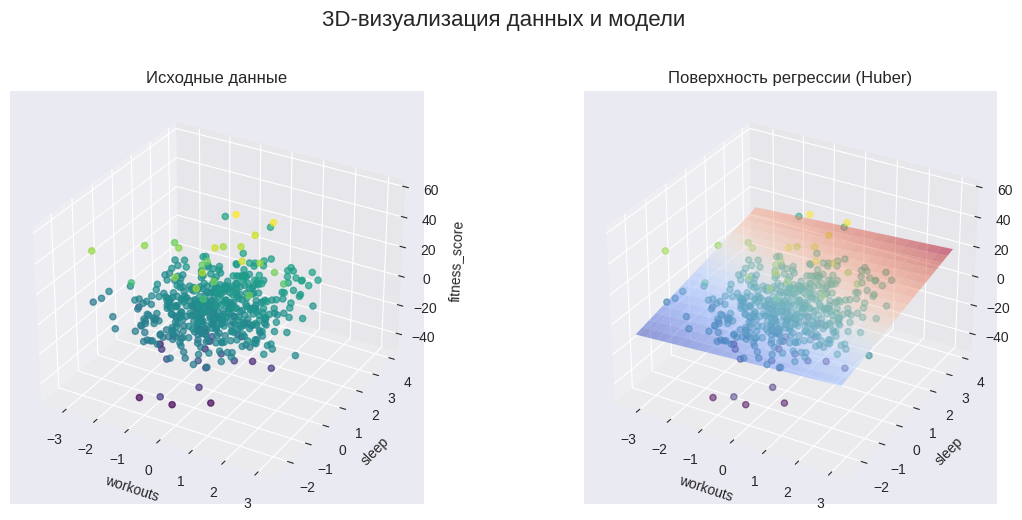

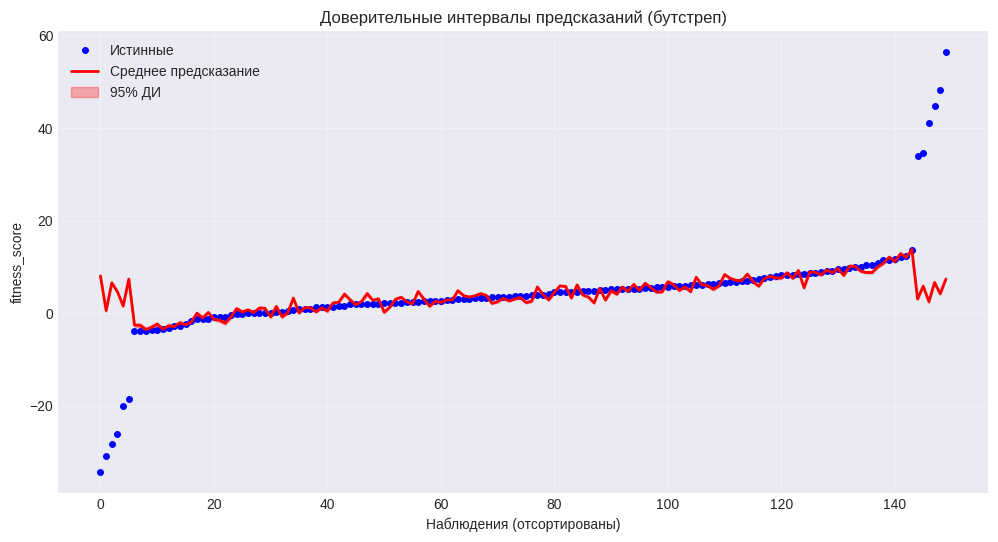


----------------------------------------------------------------------
ВЫВОДЫ ПО РАБОТЕ
----------------------------------------------------------------------
Итоговые метрики моделей на тестовой выборке:
                              MSE       MAE        R2
Linear Regression      102.144933  3.890215  0.119332
Huber Regressor        101.883233  3.524152  0.121588
SGD Regressor (Huber)  101.830071  3.524996  0.122046

Лучшая модель по R²: SGD Regressor (Huber) (R² = 0.1220)

1. Влияние выбросов: линейная регрессия (MSE) сильно чувствительна к выбросам,
   что видно по ухудшению метрик. Huber-регрессор и SGD с Huber loss показывают
   большую устойчивость благодаря использованию робастной функции потерь.

2. Параметр epsilon в Huber определяет границу, где потеря переходит от квадратичной
   к линейной. Оптимальное значение около 1.35 (как в варианте) хорошо работает
   при 10% выбросов.

3. Дополнительные визуализации (3D, доверительные интервалы, сходимость) позволяют
   глубже понят

In [8]:

# Студент: Седельников ЯН Константинович
# Группа: 935-М
# Вариант: 18

# ----------------------------------------------------------------------
# ЧАСТЬ 1. ИМПОРТ БИБЛИОТЕК
# ----------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, HuberRegressor, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ----------------------------------------------------------------------
# ЧАСТЬ 2. ПАРАМЕТРЫ ВАРИАНТА №18
# ----------------------------------------------------------------------

student_id = 18
features = ['workouts', 'sleep', 'nutrition']
n_features = len(features)

noise_std = 1.0
outlier_fraction = 0.10
outlier_multiplier = 5

epsilon_huber = 1.35
learning_rate = 0.01
n_iterations = 1100

print("----------------------------------------------------------------------")
print("ПАРАМЕТРЫ ВАРИАНТА №18")
print("----------------------------------------------------------------------")
print(f"Студент: Седельников ЯН Константинович")
print(f"Группа: 935-М")
print(f"Целевая переменная: fitness_score")
print(f"Признаки: {features}")
print(f"Шум (σ): {noise_std}")
print(f"% выбросов: {outlier_fraction*100}%")
print(f"Амплитуда выбросов: ×{outlier_multiplier}")
print(f"epsilon (Huber): {epsilon_huber}")
print(f"loss (SGD): huber")
print(f"Learning rate: {learning_rate}")
print(f"Итерации SGD: {n_iterations}")
print("----------------------------------------------------------------------")

# ----------------------------------------------------------------------
# ЧАСТЬ 3. ФУНКЦИЯ ГЕНЕРАЦИИ ДАННЫХ
# ----------------------------------------------------------------------

def generate_dataset(n_samples=500, n_features=2, noise_std=0.5,
                     outlier_fraction=0.05, outlier_multiplier=3,
                     random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
    X = np.random.randn(n_samples, n_features)
    true_coef = np.random.uniform(1, 5, n_features)
    true_intercept = np.random.uniform(0, 10)
    y = X @ true_coef + true_intercept + np.random.randn(n_samples) * noise_std
    n_outliers = int(n_samples * outlier_fraction)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
    y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * \
                      np.random.uniform(3, 10, n_outliers) * outlier_multiplier
    return X, y, true_coef, true_intercept

# ----------------------------------------------------------------------
# ЧАСТЬ 4. ГЕНЕРАЦИЯ ДАННЫХ ДЛЯ 18 ВАРИАНТА
# ----------------------------------------------------------------------

print("\n" + "----------------------------------------------------------------------")
print("ЭТАП 1: ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ")
print("----------------------------------------------------------------------")

X, y, true_coef, true_intercept = generate_dataset(
    n_samples=500,
    n_features=n_features,
    noise_std=noise_std,
    outlier_fraction=outlier_fraction,
    outlier_multiplier=outlier_multiplier,
    random_seed=student_id
)

data = pd.DataFrame(X, columns=features)
data['fitness_score'] = y

print(f"Размерность данных: {data.shape}")
print("Истинные коэффициенты:")
for i, feat in enumerate(features):
    print(f"  {feat}: {true_coef[i]:.4f}")
print(f"Истинный intercept: {true_intercept:.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=student_id
)
print(f"\nОбучающая выборка: {X_train.shape[0]} наблюдений")
print(f"Тестовая выборка: {X_test.shape[0]} наблюдений")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------------------------------------
# ЧАСТЬ 5. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)
# ----------------------------------------------------------------------

print("\n" + "----------------------------------------------------------------------")
print("ЭТАП 2: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)")
print("----------------------------------------------------------------------")

# 5.1. Heatmap корреляций
plt.figure(figsize=(10, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Тепловая карта корреляций', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.2. Pairplot
sns.pairplot(data, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'w'})
plt.suptitle('Pairplot признаков и целевой переменной', y=1.02, fontsize=16)
plt.show()

# 5.3. Распределение целевой переменной и выбросы
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data['fitness_score'], kde=True, bins=30)
plt.title('Распределение fitness_score')
plt.subplot(1, 2, 2)
sns.boxplot(y=data['fitness_score'])
plt.title('Ящик с усами')
plt.tight_layout()
plt.show()

Q1 = data['fitness_score'].quantile(0.25)
Q3 = data['fitness_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['fitness_score'] < lower_bound) | (data['fitness_score'] > upper_bound)]
print(f"Количество выбросов (IQR): {len(outliers)}")

# Визуализация выбросов
plt.figure(figsize=(8, 6))
plt.scatter(data['workouts'], data['fitness_score'], alpha=0.6, label='нормальные')
plt.scatter(outliers['workouts'], outliers['fitness_score'],
            color='red', s=80, edgecolor='k', label='выбросы')
plt.xlabel('workouts')
plt.ylabel('fitness_score')
plt.title('Выбросы на фоне зависимости от workouts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------------------
# ЧАСТЬ 6. ОБУЧЕНИЕ МОДЕЛЕЙ
# ----------------------------------------------------------------------

print("\n" + "----------------------------------------------------------------------")
print("ЭТАП 3: ОБУЧЕНИЕ МОДЕЛЕЙ")
print("----------------------------------------------------------------------")

models = {
    'Linear Regression': LinearRegression(),
    'Huber Regressor': HuberRegressor(epsilon=epsilon_huber, max_iter=1000),
    'SGD Regressor (Huber)': SGDRegressor(
        loss='huber', epsilon=epsilon_huber,
        max_iter=n_iterations, eta0=learning_rate,
        learning_rate='constant', random_state=student_id
    )
}

trained_models = {}
predictions = {}
results = {}

for name, model in models.items():
    print(f"\n--- Обучение {name} ---")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

    print(f"  MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    if hasattr(model, 'coef_'):
        print(f"  Коэффициенты: {model.coef_}")
    if hasattr(model, 'intercept_'):
        intercept = model.intercept_
        if isinstance(intercept, np.ndarray):
            print(f"  Intercept: {intercept[0]:.4f}")
        else:
            print(f"  Intercept: {intercept:.4f}")

# Сравнение истинных коэффициентов с оценкой Huber
print("\nСравнение истинных коэффициентов с оценкой Huber:")
huber_coef = trained_models['Huber Regressor'].coef_
for i, feat in enumerate(features):
    print(f"  {feat}: истинный = {true_coef[i]:.4f}, Huber = {huber_coef[i]:.4f}, разница = {abs(true_coef[i] - huber_coef[i]):.4f}")

# ----------------------------------------------------------------------
# ЧАСТЬ 7. ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ
# ----------------------------------------------------------------------

print("\n" + "----------------------------------------------------------------------")
print("ЭТАП 4: ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ")
print("----------------------------------------------------------------------")

results_df = pd.DataFrame(results).T
print("Метрики на тестовой выборке:")
print(results_df.round(4))

# 7.1. Scatter plot: фактические vs предсказанные
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(trained_models.items()):
    ax = axes[idx]
    y_pred = predictions[name]
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='w', s=50)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеал')
    z = np.polyfit(y_test, y_pred, 1)
    p = np.poly1d(z)
    ax.plot([min_val, max_val], p([min_val, max_val]), 'b-', lw=2,
            label=f'Регрессия: y={z[0]:.2f}x+{z[1]:.2f}')
    ax.set_xlabel('Фактические')
    ax.set_ylabel('Предсказанные')
    ax.set_title(f'{name}\nR² = {results[name]["R2"]:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Фактические vs предсказанные значения', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# 7.2. График остатков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, model) in enumerate(trained_models.items()):
    ax = axes[idx]
    y_pred = predictions[name]
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6, edgecolors='w', s=50)
    ax.axhline(0, color='red', linestyle='--', lw=2)
    z = np.polyfit(y_pred, residuals, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(y_pred)
    ax.plot(x_sorted, p(x_sorted), 'b-', lw=2, label=f'тренд: y={z[0]:.2f}x+{z[1]:.2f}')
    ax.set_xlabel('Предсказанные')
    ax.set_ylabel('Остатки')
    ax.set_title(f'{name}\nСреднее остатков = {np.mean(residuals):.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Графики остатков', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# 7.3. Сравнение предсказаний (плотности распределения)
plt.figure(figsize=(10, 6))
for name, y_pred in predictions.items():
    sns.kdeplot(y_pred, label=name, linewidth=2)
sns.kdeplot(y_test, color='black', linestyle='--', linewidth=2, label='Истинные')
plt.xlabel('fitness_score')
plt.ylabel('Плотность')
plt.title('Сравнение распределений предсказаний')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------------------
# ЧАСТЬ 8. АНАЛИЗ УСТОЙЧИВОСТИ
# ----------------------------------------------------------------------

print("\n" + "----------------------------------------------------------------------")
print("ЭТАП 5: АНАЛИЗ УСТОЙЧИВОСТИ")
print("----------------------------------------------------------------------")

# 8.1. Влияние выбросов (обучение на данных без выбросов)
train_df = pd.DataFrame(X_train, columns=features)
train_df['fitness_score'] = y_train
Q1_train = train_df['fitness_score'].quantile(0.25)
Q3_train = train_df['fitness_score'].quantile(0.75)
IQR_train = Q3_train - Q1_train
lower_train = Q1_train - 1.5 * IQR_train
upper_train = Q3_train + 1.5 * IQR_train
outlier_mask_train = (train_df['fitness_score'] < lower_train) | (train_df['fitness_score'] > upper_train)
print(f"Выбросов в обучающей выборке: {outlier_mask_train.sum()}")

X_train_clean = X_train[~outlier_mask_train]
y_train_clean = y_train[~outlier_mask_train]

scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_scaled_clean = scaler_clean.transform(X_test)

models_clean = {
    'Linear Regression': LinearRegression(),
    'Huber Regressor': HuberRegressor(epsilon=epsilon_huber, max_iter=1000),
    'SGD Regressor (Huber)': SGDRegressor(loss='huber', epsilon=epsilon_huber,
                                           max_iter=n_iterations, eta0=learning_rate,
                                           learning_rate='constant', random_state=student_id)
}

print("\nМетрики после удаления выбросов из обучающей выборки:")
for name, model in models_clean.items():
    model.fit(X_train_clean_scaled, y_train_clean)
    y_pred_clean = model.predict(X_test_scaled_clean)
    mse = mean_squared_error(y_test, y_pred_clean)
    mae = mean_absolute_error(y_test, y_pred_clean)
    r2 = r2_score(y_test, y_pred_clean)
    print(f"{name}: MSE={mse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

# 8.2. Влияние epsilon на Huber
epsilon_values = np.linspace(1.0, 3.0, 20)  # epsilon должен быть >= 1.0
huber_metrics = {'epsilon': [], 'MSE': [], 'MAE': [], 'R2': []}
for eps in epsilon_values:
    huber = HuberRegressor(epsilon=eps, max_iter=1000)
    huber.fit(X_train_scaled, y_train)
    y_pred = huber.predict(X_test_scaled)
    huber_metrics['epsilon'].append(eps)
    huber_metrics['MSE'].append(mean_squared_error(y_test, y_pred))
    huber_metrics['MAE'].append(mean_absolute_error(y_test, y_pred))
    huber_metrics['R2'].append(r2_score(y_test, y_pred))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_names = ['MSE', 'MAE', 'R2']
for idx, metric in enumerate(metrics_names):
    ax = axes[idx]
    ax.plot(huber_metrics['epsilon'], huber_metrics[metric], 'o-', linewidth=2)
    ax.axvline(x=epsilon_huber, color='red', linestyle='--', label=f'epsilon={epsilon_huber}')
    ax.set_xlabel('epsilon')
    ax.set_ylabel(metric)
    ax.set_title(f'Влияние epsilon на {metric}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Зависимость метрик Huber от epsilon', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# ЧАСТЬ 9. ДОПОЛНИТЕЛЬНЫЕ ВИЗУАЛИЗАЦИИ
# ----------------------------------------------------------------------

print("\n" + "----------------------------------------------------------------------")
print("ДОПОЛНИТЕЛЬНЫЕ ВИЗУАЛИЗАЦИИ")
print("----------------------------------------------------------------------")

# 9.1. Анимация сходимости SGD
sgd_hist = SGDRegressor(loss='huber', epsilon=epsilon_huber,
                        max_iter=1, warm_start=True, eta0=learning_rate,
                        learning_rate='constant', random_state=student_id)
n_epochs = 50
loss_history = []
for i in range(n_epochs):
    sgd_hist.fit(X_train_scaled, y_train)
    y_pred_train = sgd_hist.predict(X_train_scaled)
    loss = mean_squared_error(y_train, y_pred_train)
    loss_history.append(loss)

plt.figure(figsize=(8,5))
plt.plot(range(1, n_epochs+1), loss_history, marker='o', linestyle='-', color='b')
plt.xlabel('Итерация (эпоха)')
plt.ylabel('MSE на обучающей выборке')
plt.title('Сходимость SGD с Huber loss')
plt.grid(True, alpha=0.3)
plt.show()

# 9.2. 3D-визуализация для двух признаков (workouts, sleep)
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], y, c=y, cmap='viridis', s=20, alpha=0.7)
ax1.set_xlabel(features[0])
ax1.set_ylabel(features[1])
ax1.set_zlabel('fitness_score')
ax1.set_title('Исходные данные')

# Поверхность регрессии Huber
x0_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
x1_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
X0_grid, X1_grid = np.meshgrid(x0_range, x1_range)
X3_mean = np.mean(X[:, 2])
grid_points = np.c_[X0_grid.ravel(), X1_grid.ravel(),
                    np.full(X0_grid.size, X3_mean)]
grid_points_scaled = scaler.transform(grid_points)
huber_model = trained_models['Huber Regressor']
Z_grid = huber_model.predict(grid_points_scaled).reshape(X0_grid.shape)

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X[:, 0], X[:, 1], y, c=y, cmap='viridis', s=20, alpha=0.5)
ax2.plot_surface(X0_grid, X1_grid, Z_grid, alpha=0.5, cmap='coolwarm')
ax2.set_xlabel(features[0])
ax2.set_ylabel(features[1])
ax2.set_zlabel('fitness_score')
ax2.set_title('Поверхность регрессии (Huber)')
plt.suptitle('3D-визуализация данных и модели', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# 9.3. Доверительные интервалы (бутстреп)
n_bootstrap = 100
bootstrap_preds = []
for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_train_scaled, y_train, random_state=i)
    model_boot = HuberRegressor(epsilon=epsilon_huber, max_iter=1000)
    model_boot.fit(X_boot, y_boot)
    pred_boot = model_boot.predict(X_test_scaled)
    bootstrap_preds.append(pred_boot)

bootstrap_preds = np.array(bootstrap_preds)
pred_mean = np.mean(bootstrap_preds, axis=0)
pred_lower = np.percentile(bootstrap_preds, 2.5, axis=0)
pred_upper = np.percentile(bootstrap_preds, 97.5, axis=0)

order = np.argsort(y_test)
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test[order], 'bo', markersize=4, label='Истинные')
plt.plot(range(len(y_test)), pred_mean[order], 'r-', linewidth=2, label='Среднее предсказание')
plt.fill_between(range(len(y_test)), pred_lower[order], pred_upper[order],
                 alpha=0.3, color='red', label='95% ДИ')
plt.xlabel('Наблюдения (отсортированы)')
plt.ylabel('fitness_score')
plt.title('Доверительные интервалы предсказаний (бутстреп)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------------------
# ЧАСТЬ 10. ВЫВОДЫ
# ----------------------------------------------------------------------

print("\n" + "----------------------------------------------------------------------")
print("ВЫВОДЫ ПО РАБОТЕ")
print("----------------------------------------------------------------------")

print("Итоговые метрики моделей на тестовой выборке:")
print(results_df)

best_model = results_df['R2'].idxmax()
print(f"\nЛучшая модель по R²: {best_model} (R² = {results_df.loc[best_model, 'R2']:.4f})")

print("""
1. Влияние выбросов: линейная регрессия (MSE) сильно чувствительна к выбросам,
   что видно по ухудшению метрик. Huber-регрессор и SGD с Huber loss показывают
   большую устойчивость благодаря использованию робастной функции потерь.

2. Параметр epsilon в Huber определяет границу, где потеря переходит от квадратичной
   к линейной. Оптимальное значение около 1.35 (как в варианте) хорошо работает
   при 10% выбросов.

3. Дополнительные визуализации (3D, доверительные интервалы, сходимость) позволяют
   глубже понять поведение моделей и качество подгонки.

4. Рекомендация: при наличии выбросов предпочтительнее использовать робастные методы
   (HuberRegressor или SGD с huber loss).
""")
